<a href="https://colab.research.google.com/github/M-Abbi/Financial-Modeling/blob/main/2_A_quantitative_approach_to_progress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A Quantitative Visual Guide to Progress: Beyond Static Metrics

Inspired by Roman Paolucci's analysis, this notebook explores how we quantify "getting better." Most people look at their progress linearly, but with a quant approach, we know that progress is a **non-stationary process**.

### The Problem with "Stale" Thinking
In traditional statistics, we often look at the **Cumulative Mean**. However, if you are actually improving, your "past self" (the lower scores from when you started) will act as a weight, dragging down your current average and giving you a false sense of where you actually stand.

We will simulate a progress journey to visualize the difference between **Cumulative** and **Rolling** metrics.

In [3]:
## This block creates a "Progress Time Series" where the true level improves over time, but each realization has noise (variance).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup Data
np.random.seed(42)
days = 100
time = np.arange(days)

# Progress: True ability increases over time (the "Black Line")
true_level = 10 + 0.15 * time

# Realizations: Noise around the true level (the "Red Dots")
# We add random variance to simulate daily performance fluctuations
noise = np.random.normal(0, 2.5, days)
realizations = true_level + noise

df = pd.DataFrame({'Day': time, 'Performance': realizations})

### Analysis: The Failure of Cumulative Metrics

Observe the blue line above. Notice how, as time progresses, the gap between the **Daily Realizations (Red Dots)** and the **Cumulative Mean (Blue Line)** grows wider.

**Why this is frustrating:**
* **Lag:** The mean is "stale." It includes data from Day 1 when you knew nothing, which punishes you for your history.
* **Exploding Variance:** Because the mean is stuck in the past, the "variance" (the shaded area) looks massive. It suggests you might still perform at a "Day 1" level, even though your current skill has moved far beyond that.

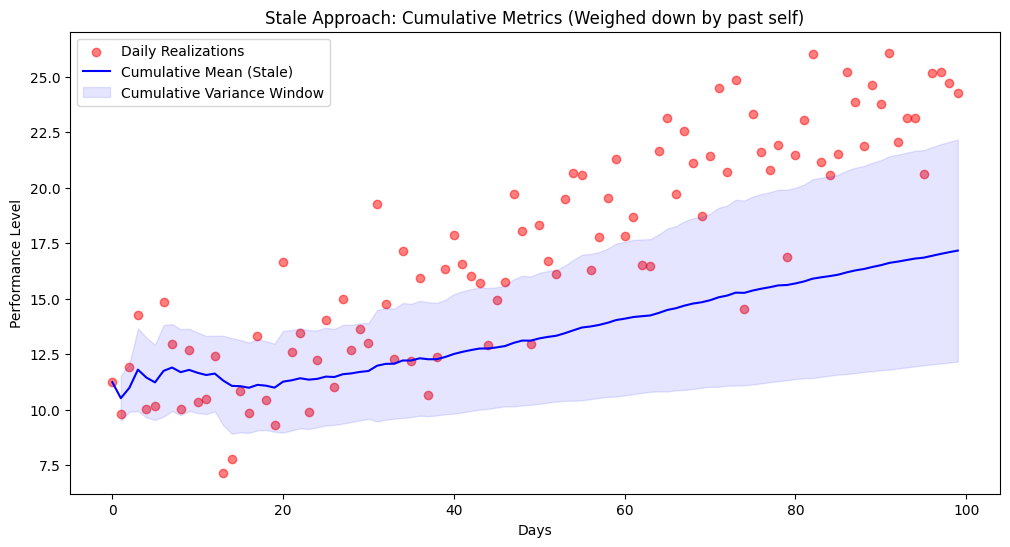

In [4]:
# 2. Cumulative Calculations
df['cum_mean'] = df['Performance'].expanding().mean()
df['cum_std'] = df['Performance'].expanding().std()

plt.figure(figsize=(12, 6))
plt.scatter(df['Day'], df['Performance'], color='red', alpha=0.5, label='Daily Realizations')
plt.plot(df['Day'], df['cum_mean'], color='blue', label='Cumulative Mean (Stale)')
plt.fill_between(df['Day'],
                 df['cum_mean'] - df['cum_std'],
                 df['cum_mean'] + df['cum_std'],
                 color='blue', alpha=0.1, label='Cumulative Variance Window')

plt.title("Stale Approach: Cumulative Metrics (Weighed down by past self)")
plt.xlabel("Days")
plt.ylabel("Performance Level")
plt.legend()
plt.show()

### The Quant Solution: Rolling Windows

To capture **Progress**, we must use a **Rolling Window** (in this case, 7 days). This shifts our focus from "How have I done overall?" to "How am I performing *now*?"

This approach treats progress as a moving target, allowing us to:
1.  **Track the "True Level":** The black line represents our current ability.
2.  **Define the Variance Window:** The gray area shows our potential "good days" and "bad days" relative to our *current* skill, not our beginner skill.

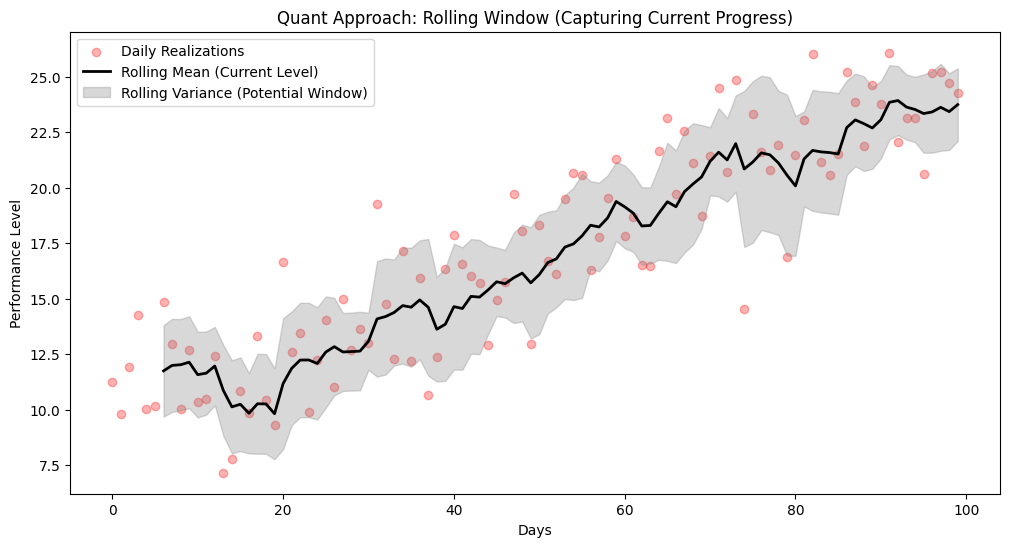

In [5]:
# 3. Rolling Calculations (Window = 7 days)
window = 7
df['rolling_mean'] = df['Performance'].rolling(window=window).mean()
df['rolling_std'] = df['Performance'].rolling(window=window).std()

plt.figure(figsize=(12, 6))
plt.scatter(df['Day'], df['Performance'], color='red', alpha=0.3, label='Daily Realizations')
plt.plot(df['Day'], df['rolling_mean'], color='black', linewidth=2, label='Rolling Mean (Current Level)')
plt.fill_between(df['Day'],
                 df['rolling_mean'] - df['rolling_std'],
                 df['rolling_mean'] + df['rolling_std'],
                 color='gray', alpha=0.3, label='Rolling Variance (Potential Window)')

plt.title("Quant Approach: Rolling Window (Capturing Current Progress)")
plt.xlabel("Days")
plt.ylabel("Performance Level")
plt.legend()
plt.show()

### Conclusion: Progress is Nonlinear

The final graph reveals a vital psychological truth: **A bad day (a low red dot) does not mean you've regressed.**

As long as the **Rolling Mean (Black Line)** is trending upward, you are progressing. A low realization on Day 80 might still be higher than a "great day" on Day 10. By using rolling metrics, we remove the "noise" of the past and focus on the trajectory of the future.